# Rank, Null Space, and Linear Systems

**Goal:** Understand rank, column space, null space, and how to solve $Ax = b$.

**Reference:** Mathematics for ML - Chapter 2.5–2.7

## Linear Systems

A system of linear equations can be written as:

$$A \mathbf{x} = \mathbf{b}$$

- $A$: coefficient matrix ($m \times n$)
- $\mathbf{x}$: unknowns ($n \times 1$)
- $\mathbf{b}$: result vector ($m \times 1$)

**Three cases:**
1. **Unique solution** — $A$ is square and invertible
2. **No solution** — system is inconsistent
3. **Infinite solutions** — system is underdetermined

In [14]:
import numpy as np 
import matplotlib.pyplot as plt 

## Gaussian Elimination

To solve $Ax = b$, we transform the augmented matrix $[A | b]$ into **row echelon form** using elementary row operations:

1. Swap two rows
2. Multiply a row by a nonzero scalar
3. Add a multiple of one row to another

**Row echelon form** has:
- The first nonzero entry (pivot) of each row is to the right of the pivot above it
- Rows of all zeros are at the bottom

In [ ]:
def gaussian_elimination(A, b):
    A = [row[:] for row in A]  
    b = b[:]
    n = len(A)

    # Forward elimination
    for i in range(n):
        
        max_row = max(range(i, n), key=lambda r: abs(A[r][i]))
        if abs(A[max_row][i]) < 1e-12:
            return None  
        A[i], A[max_row] = A[max_row], A[i]
        b[i], b[max_row] = b[max_row], b[i]

        # Eliminate below pivot
        for j in range(i + 1, n):
            factor = A[j][i] / A[i][i]
            for k in range(i, n):
                A[j][k] -= factor * A[i][k]
            b[j] -= factor * b[i]

    # Back substitution
    x = [0] * n
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - sum(A[i][j] * x[j] for j in range(i + 1, n))) / A[i][i]
    return x


# Test
A = [[2, 1, -1],
     [-3, -1, 2],
     [-2, 1, 2]]
b = [8, -11, -3]

x = gaussian_elimination(A, b)
print("My solution:   ", x)
print("NumPy solution:", np.linalg.solve(A, b).tolist())

My solution:    [2.0, 3.0000000000000004, -0.9999999999999999]
NumPy solution: [2.0000000000000004, 2.9999999999999996, -0.9999999999999994]


## Rank of a Matrix

The **rank** of $A$ is the number of **linearly independent rows (or columns)**.

Equivalently, it's the number of **pivots** after Gaussian elimination.

**Key facts:**
- $\text{rank}(A) \leq \min(m, n)$
- If $\text{rank}(A) = \min(m, n)$, $A$ has **full rank**
- If $\text{rank}(A) < \min(m, n)$, $A$ is **rank-deficient**
- $\text{rank}(A) = n$ (for square $A$) ⟺ $A$ is invertible ⟺ $\det(A) \neq 0$

**Why it matters for ML:**
- Rank-deficient feature matrix → multicollinearity → unstable regression
- Low-rank approximations → PCA, matrix factorization, recommender systems

In [ ]:
def rank(A):
    """Compute rank by counting pivots after Gaussian elimination."""
    A = [row[:] for row in A]
    m = len(A)
    n = len(A[0])
    r = 0  

    for col in range(n):
        pivot_row = None
        for row in range(r, m):
            if abs(A[row][col]) > 1e-12:
                pivot_row = row
                break

        if pivot_row is None:
            continue 

        
        A[r], A[pivot_row] = A[pivot_row], A[r]

        
        pivot = A[r][col]
        A[r] = [x / pivot for x in A[r]]

        
        for row in range(m):
            if row != r and abs(A[row][col]) > 1e-12:
                factor = A[row][col]
                A[row] = [A[row][k] - factor * A[r][k] for k in range(n)]

        r += 1
        if r == m:
            break
    return r


# Test
tests = [
    ([[1, 2], [3, 4]], "full rank 2x2"),
    ([[1, 2], [2, 4]], "rank 1 (rows dependent)"),
    ([[1, 2, 3], [4, 5, 6], [7, 8, 9]], "rank 2"),
    ([[1, 2, 3], [4, 5, 6]], "tall matrix, rank 2"),
]
for A, desc in tests:
    print(f"{desc:30s} My: {rank(A)}  NumPy: {np.linalg.matrix_rank(A)}")

full rank 2x2                  My: 2  NumPy: 2
rank 1 (rows dependent)        My: 1  NumPy: 1
rank 2                         My: 2  NumPy: 2
tall matrix, rank 2            My: 2  NumPy: 2


## Null Space (Kernel)

The **null space** of $A$ is the set of all vectors $\mathbf{x}$ such that:

$$A \mathbf{x} = \mathbf{0}$$

**Intuition:** directions that $A$ collapses to zero.

**Dimension formula (Rank-Nullity Theorem):**

$$\text{rank}(A) + \text{nullity}(A) = n$$

where $n$ is the number of columns.

**Why it matters for ML:**
- Non-trivial null space → multiple solutions to $Ax = b$
- Kernel methods (SVMs) rely on null space concepts
- Null space dimension tells you how many "free" directions exist

In [ ]:
def null_space(A, tol=1e-12):
   
    A = [row[:] for row in A]
    m = len(A)
    n = len(A[0])
    pivots = []

    # Reduce to row echelon form, tracking pivot columns
    r = 0
    for col in range(n):
        pivot_row = None
        for row in range(r, m):
            if abs(A[row][col]) > tol:
                pivot_row = row
                break
        if pivot_row is None:
            continue
        A[r], A[pivot_row] = A[pivot_row], A[r]
        pivot = A[r][col]
        A[r] = [x / pivot for x in A[r]]
        for row in range(m):
            if row != r and abs(A[row][col]) > tol:
                factor = A[row][col]
                A[row] = [A[row][k] - factor * A[r][k] for k in range(n)]
        pivots.append(col)
        r += 1
        if r == m:
            break

    free_cols = [c for c in range(n) if c not in pivots]

    # Build basis vectors: one per free column
    basis = []
    for free in free_cols:
        vec = [0] * n
        vec[free] = 1
        for i, pcol in enumerate(pivots):
            vec[pcol] = -A[i][free]
        basis.append(vec)
    return basis


# Test
A = [[1, 2, 3],
     [4, 5, 6],
     [7, 8, 9]]

basis = null_space(A)
print("Null space basis vectors:")
for v in basis:
    print(" ", v)
    print("  A @ v =", np.array(A) @ np.array(v))

Null space basis vectors:
  [1.0, -2.0, 1]
  A @ v = [0. 0. 0.]


## Visualizing Solution Spaces

For a 2D system $Ax = b$:
- Each equation is a line
- The solution is the **intersection**
- Rank tells you whether lines intersect at a point (rank 2), along a line (rank 1), or never (inconsistent)

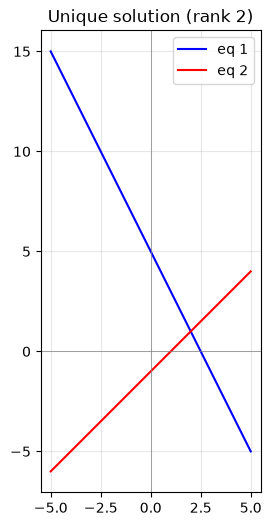

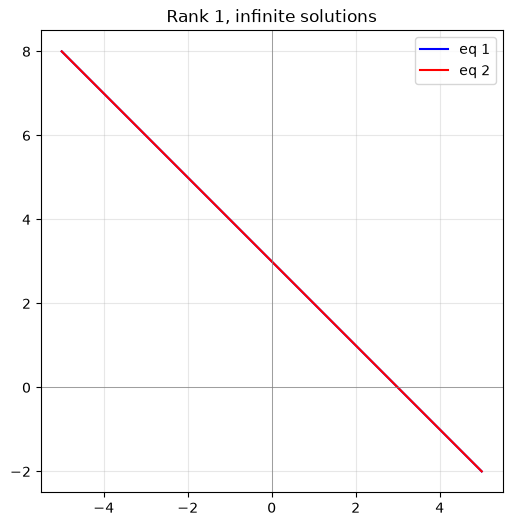

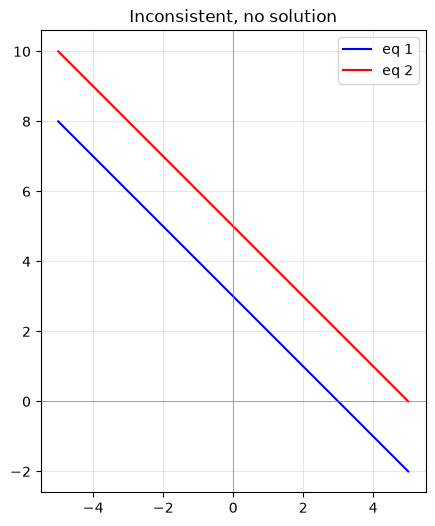

In [18]:
def plot_system(A, b, title=""):
    """Plot two lines representing a 2x2 system Ax = b."""
    x_vals = np.linspace(-5, 5, 100)

    fig, ax = plt.subplots(figsize=(6, 6))

    colors = ['blue', 'red']
    for i in range(2):
        a1, a2 = A[i]
        # a1*x + a2*y = b[i]  →  y = (b[i] - a1*x) / a2
        if abs(a2) > 1e-12:
            y_vals = (b[i] - a1 * x_vals) / a2
            ax.plot(x_vals, y_vals, color=colors[i], label=f"eq {i+1}")

    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_title(title or f"rank(A) = {rank(A)}")
    ax.set_aspect('equal')
    plt.show()


# Unique solution (rank 2)
plot_system([[2, 1], [1, -1]], [5, 1], title="Unique solution (rank 2)")

# Dependent rows (rank 1, infinite solutions)
plot_system([[1, 1], [2, 2]], [3, 6], title="Rank 1, infinite solutions")

# Inconsistent
plot_system([[1, 1], [1, 1]], [3, 5], title="Inconsistent, no solution")

## Key Takeaways

- **Gaussian elimination** transforms $[A|b]$ into row echelon form to solve systems
- **Rank** = number of pivots = dimension of column space
- **Null space** = vectors $x$ with $Ax = 0$
- **Rank-Nullity:** $\text{rank}(A) + \text{nullity}(A) = n$
- **Full rank** ⟺ unique solution ⟺ invertible (square case)

## Connection to ML

- **Least squares** when $Ax = b$ has no exact solution (overdetermined)
- **Regularization (Ridge)** handles rank-deficient $X^T X$
- **PCA** finds low-rank structure in data
- **Kernel methods** rely on null space and column space concepts